In [1]:
!pip install httpx pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Agentic Trader — Exploratory Data Analysis
### This notebook analyzes Bitcoin (BTC), Ethereum (ETH), and Binance Coin (BNB) using daily and hourly price data sourced from the Binance public API. The purpose is to explore market behavior, compute key technical indicators, and illustrate a simple rule-based strategy for momentum and volatility analysis. Daily data is used for descriptive statistics, correlation, and volatility regime analysis, while hourly data supports feature engineering, clustering, and backtesting of short-term trading signals.

## Section 1: Data Collection

In [2]:
import httpx
import pandas as pd
import numpy as np

KLINES_URL = "https://api.binance.com/api/v3/klines"
_KLINES_COLS = [
    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "num_trades",
    "taker_buy_base", "taker_buy_quote", "ignore",
]


def fetch_daily(symbol: str, limit: int = 365) -> pd.DataFrame:
    """Fetch daily OHLCV candles from Binance for a given symbol."""
    resp = httpx.get(
        KLINES_URL,
        params={"symbol": symbol, "interval": "1d", "limit": limit},
        timeout=15.0,
    )
    resp.raise_for_status()
    df = pd.DataFrame(resp.json(), columns=_KLINES_COLS)
    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms")
    for col in ("open", "high", "low", "close", "volume"):
        df[col] = df[col].astype(float)
    return df[["timestamp", "open", "high", "low", "close", "volume"]].set_index("timestamp")


btc = fetch_daily("BTCUSDT")
eth = fetch_daily("ETHUSDT")
bnb = fetch_daily("BNBUSDT")

print("BTC shape:", btc.shape)
btc.head()

BTC shape: (365, 5)


,open,high,low,close,volume
timestamp,,,,,
2025-04-06,83537.99,83817.63,77153.83,78430.00,27942.71436
2025-04-07,78430.00,81243.58,74508.00,79163.24,78387.53089
2025-04-08,79163.24,80867.99,76239.90,76322.42,35317.32063
2025-04-09,76322.42,83588.00,74620.00,82615.22,75488.28772
2025-04-10,82615.22,82753.21,78464.36,79607.30,33284.80718


In [3]:
print("ETH shape:", eth.shape)
print("BNB shape:", bnb.shape)

ETH shape: (365, 5)
BNB shape: (365, 5)


### For this analysis, historical daily price data was obtained via the Binance API. Specifically, 365 days of OHLCV (Open, High, Low, Close, Volume) data were collected for Bitcoin (BTC), Ethereum (ETH), and BNB. This dataset provides a consistent time frame for comparing price movements, volatility, and trading activity across the three cryptocurrencies.

## Section 2: Cleaning

In [4]:
# Null value check
print("=== Null counts before ffill ===")
for name, df in [("BTC", btc), ("ETH", eth), ("BNB", bnb)]:
    print(f"\n{name}:")
    print(df.isnull().sum())

=== Null counts before ffill ===

BTC:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

ETH:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

BNB:
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [5]:
# OHLCV integrity: high >= low
for name, df in [("BTC", btc), ("ETH", eth), ("BNB", bnb)]:
    violations = df[df["high"] < df["low"]]
    if violations.empty:
        print(f"{name}: no high < low violations")
    else:
        print(f"{name}: {len(violations)} violation(s)!")
        print(violations)

BTC: no high < low violations
ETH: no high < low violations
BNB: no high < low violations


In [6]:
# Apply forward-fill and confirm null counts after
btc = btc.ffill()
eth = eth.ffill()
bnb = bnb.ffill()

print("=== Null counts after ffill ===")
for name, df in [("BTC", btc), ("ETH", eth), ("BNB", bnb)]:
    print(f"{name}: {df.isnull().sum().sum()} nulls remaining")

=== Null counts after ffill ===
BTC: 0 nulls remaining
ETH: 0 nulls remaining
BNB: 0 nulls remaining


### First, we checked whether the datasets contained any missing values before cleaning. There were no missing values for the three cryptocurrencies. Next, we assessed data quality by verifying whether any rows had a highest price lower than the lowest price. Finally, we applied forward fill (ffill) as a precaution against potential gaps caused by exchange downtime. Forward fill replaces missing values with the last known valid value from the previous observation.

## Section 3: Descriptive Statistics

In [7]:
def describe_returns(df: pd.DataFrame, name: str) -> dict:
    returns = df["close"].pct_change().dropna()
    return {
        "mean_return": returns.mean(),
        "std": returns.std(),
        "skewness": returns.skew(),
        "kurtosis": returns.kurtosis(),
    }

stats = pd.DataFrame(
    {
        "BTC": describe_returns(btc, "BTC"),
        "ETH": describe_returns(eth, "ETH"),
        "BNB": describe_returns(bnb, "BNB"),
    }
).round(6)

stats

,BTC,ETH,BNB
mean_return,-0.000171,0.001441,0.000552
std,0.022809,0.038709,0.027162
skewness,-0.048146,0.729796,-0.041136
kurtosis,6.429074,4.150979,5.198830


### Computed basic statistics to gain a clearer understanding of the data.
### a) mean_return: average daily return
### b) std: standard deviation (volatility)
### c) skewness: indicates whether returns are asymmetric 
        positive → more extreme gains
        negative → more extreme losses
### d) kurtosis: higher values indicate fat tails, meaning extreme price movements are more likely than in a normal distribution
### These descriptive statistics were calculated for all three cryptocurrencies.

## Section 4: Time-Series Visualisation

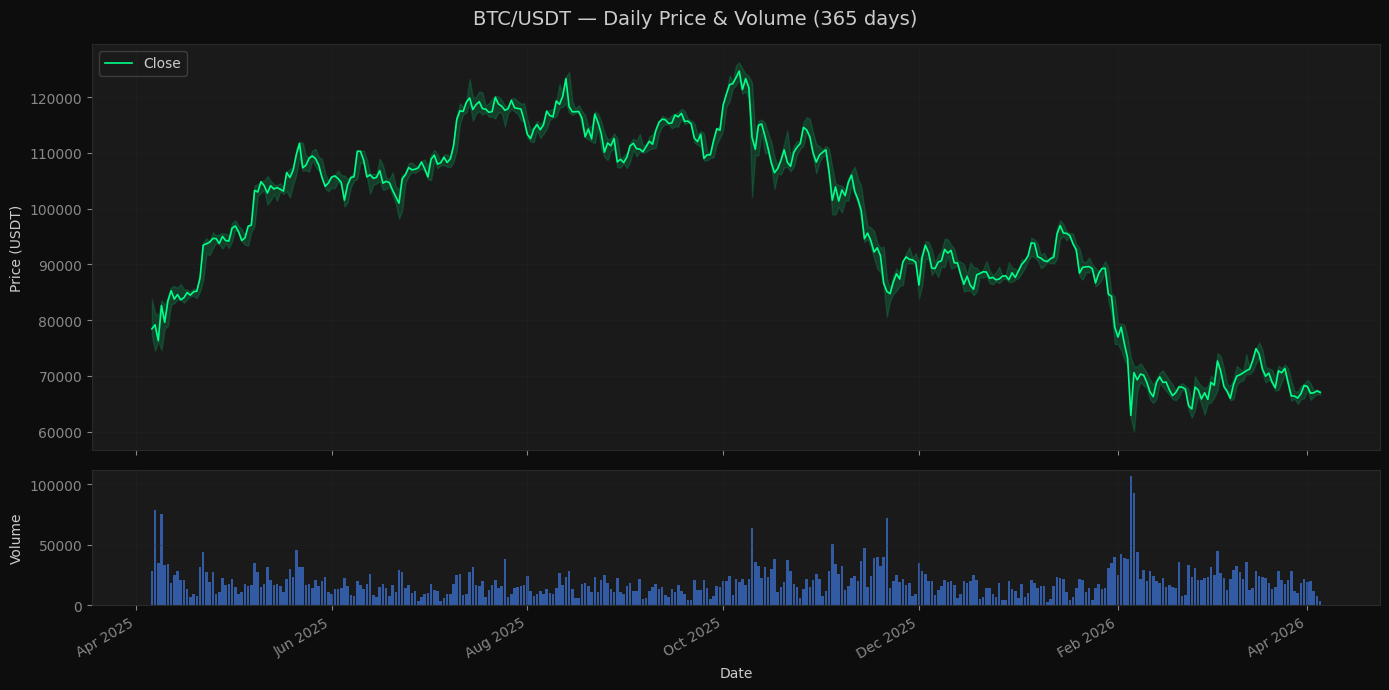

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor": "#1a1a1a",
    "axes.edgecolor": "#2a2a2a",
    "axes.labelcolor": "#cccccc",
    "xtick.color": "#888888",
    "ytick.color": "#888888",
    "grid.color": "#2a2a2a",
    "text.color": "#cccccc",
    "lines.color": "#00ff88",
})

fig, (ax_price, ax_vol) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                        gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("BTC/USDT — Daily Price & Volume (365 days)", color="#cccccc", fontsize=14)

ax_price.plot(btc.index, btc["close"], color="#00ff88", linewidth=1.2, label="Close")
ax_price.fill_between(btc.index, btc["low"], btc["high"], alpha=0.15, color="#00ff88")
ax_price.set_ylabel("Price (USDT)", fontsize=10)
ax_price.grid(True, alpha=0.3)
ax_price.legend(loc="upper left", framealpha=0.2)

ax_vol.bar(btc.index, btc["volume"], color="#4488ff", alpha=0.6, width=0.8, label="Volume")
ax_vol.set_ylabel("Volume", fontsize=10)
ax_vol.set_xlabel("Date", fontsize=10)
ax_vol.grid(True, alpha=0.3)
ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_vol.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


### Created a dark-themed chart showing Bitcoin’s price and trading volume over the past year. The top chart displays how Bitcoin’s price changed over time, while the bottom chart shows daily trading volume. This visualization allows for the identification of notable price regimes and volume spikes that correlate with price movements. It is useful for spotting bullish and bearish trends, assessing volatility through price ranges, and detecting unusual trading activity that may signal significant market events.

## Section 5: Volatility Analysis

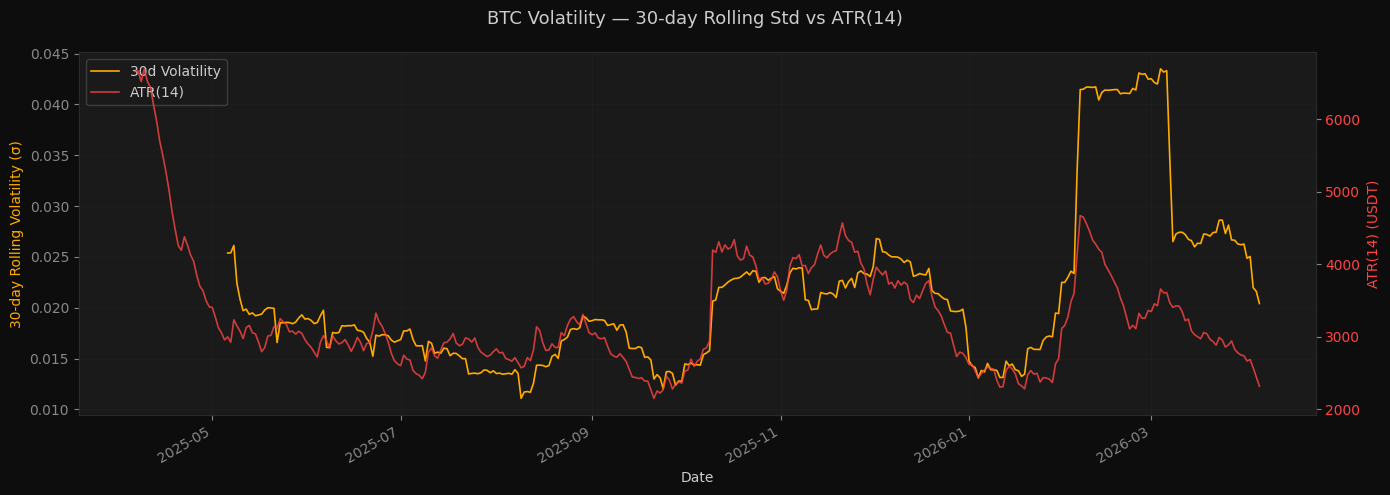

In [9]:
# Rolling 30-day std of daily returns
btc_returns = btc["close"].pct_change()
rolling_vol = btc_returns.rolling(30).std()

# ATR(14) — manual computation
prev_close = btc["close"].shift(1)
tr = pd.concat(
    [
        btc["high"] - btc["low"],
        (btc["high"] - prev_close).abs(),
        (btc["low"] - prev_close).abs(),
    ],
    axis=1,
).max(axis=1)
atr14 = tr.ewm(com=13, adjust=False).mean()

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0d0d0d")
ax1.set_facecolor("#1a1a1a")

color_vol = "#ffaa00"
ax1.set_xlabel("Date", color="#cccccc")
ax1.set_ylabel("30-day Rolling Volatility (σ)", color=color_vol)
ax1.plot(btc.index, rolling_vol, color=color_vol, linewidth=1.2, label="30d Volatility")
ax1.tick_params(axis="y", labelcolor=color_vol)
ax1.tick_params(colors="#888888")
ax1.grid(True, alpha=0.3, color="#2a2a2a")

ax2 = ax1.twinx()
ax2.set_facecolor("#1a1a1a")
color_atr = "#ff4444"
ax2.set_ylabel("ATR(14) (USDT)", color=color_atr)
ax2.plot(btc.index, atr14, color=color_atr, linewidth=1.2, alpha=0.8, label="ATR(14)")
ax2.tick_params(axis="y", labelcolor=color_atr)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.2)

fig.suptitle("BTC Volatility — 30-day Rolling Std vs ATR(14)", color="#cccccc", fontsize=13)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

### For volatility analysis, I created a dual-axis chart comparing Bitcoin’s short-term volatility using two measures: the 30-day rolling standard deviation of returns and ATR(14). True Range (TR) is calculated as max(high - low, abs(high - previous close), abs(low - previous close)), and ATR(14) is the 14-period exponential moving average of TR. Elevated ATR periods indicate higher market risk and define quantitative volatility regimes. The rolling standard deviation reflects relative return volatility, while ATR measures absolute price volatility.

## Section 6: Correlation Matrix

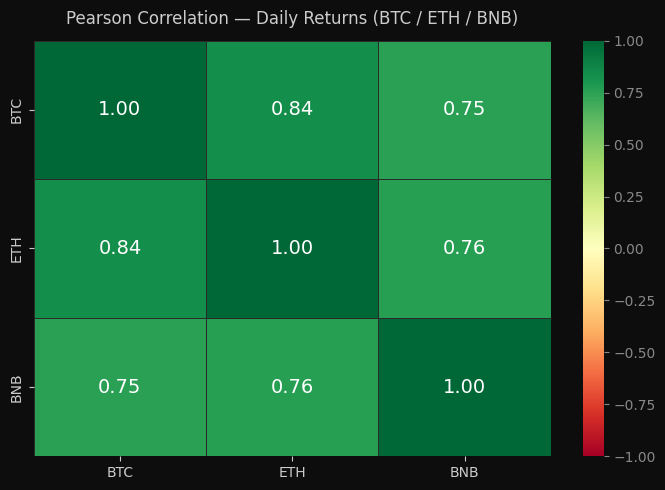


Correlation matrix:
       BTC    ETH    BNB
BTC  1.000  0.838  0.750
ETH  0.838  1.000  0.759
BNB  0.750  0.759  1.000


In [10]:
import seaborn as sns

returns_df = pd.DataFrame({
    "BTC": btc["close"].pct_change(),
    "ETH": eth["close"].pct_change(),
    "BNB": bnb["close"].pct_change(),
}).dropna()

corr = returns_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#1a1a1a")

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="#2a2a2a",
    annot_kws={"size": 14, "color": "white"},
    ax=ax,
)
ax.set_title("Pearson Correlation — Daily Returns (BTC / ETH / BNB)",
             color="#cccccc", fontsize=12, pad=12)
ax.tick_params(colors="#cccccc")
plt.tight_layout()
plt.show()

print("\nCorrelation matrix:")
print(corr.round(3))

### This code analyses the relationship between Bitcoin, Ethereum, and BNB by computing and visualising the correlation of their daily returns. First, daily percentage returns are calculated from closing prices using pct_change(), and missing values are removed. A Pearson correlation matrix is then computed to measure the linear relationship between the returns of the three cryptocurrencies.

### The results are visualised using a heatmap, where values range from -1 to 1. Positive values (shown in green) indicate that assets tend to move in the same direction, while negative values (shown in red) indicate opposite movements. The strength of the colour reflects the magnitude of the correlation.

### This analysis is useful for identifying how closely the assets move together, which is important for portfolio diversification and risk management. High correlation suggests limited diversification benefits, while lower correlation indicates more independent price behaviour.

## Section 7: K-Means Clustering

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Fetch BTC 1h candles (500 candles)
resp_1h = httpx.get(
    KLINES_URL,
    params={"symbol": "BTCUSDT", "interval": "1h", "limit": 500},
    timeout=15.0,
)
resp_1h.raise_for_status()
btc1h = pd.DataFrame(resp_1h.json(), columns=_KLINES_COLS)
btc1h["timestamp"] = pd.to_datetime(btc1h["open_time"], unit="ms")
for col in ("open", "high", "low", "close", "volume"):
    btc1h[col] = btc1h[col].astype(float)
btc1h = btc1h.set_index("timestamp")
print("BTC 1h shape:", btc1h.shape)

BTC 1h shape: (500, 12)


In [12]:
# --- Feature computation (manual pandas, no pandas-ta) ---

close_1h = btc1h["close"]

# RSI(14)
delta = close_1h.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs = avg_gain / avg_loss.replace(0, float("nan"))
rsi_1h = 100 - (100 / (1 + rs))

# MACD histogram (12, 26, 9)
ema12 = close_1h.ewm(span=12, adjust=False).mean()
ema26 = close_1h.ewm(span=26, adjust=False).mean()
macd_line_1h = ema12 - ema26
signal_line_1h = macd_line_1h.ewm(span=9, adjust=False).mean()
macd_hist_1h = macd_line_1h - signal_line_1h

# Volume vs 20-period average
volume_avg = btc1h["volume"].rolling(20).mean()
volume_vs_avg = btc1h["volume"] / volume_avg

# Assemble feature DataFrame and drop NaNs
features_df = pd.DataFrame({
    "rsi": rsi_1h,
    "macd_hist": macd_hist_1h,
    "volume_vs_avg": volume_vs_avg,
}).dropna()

print("Feature matrix shape:", features_df.shape)
features_df.describe().round(4)

Feature matrix shape: (481, 3)


,rsi,macd_hist,volume_vs_avg
count,481.0000,481.0000,481.0000
mean,47.3742,-4.0706,0.9949
std,12.2538,105.1935,0.6534
min,15.0784,-317.6485,0.0588
25%,38.4609,-60.6377,0.5939
50%,48.7905,4.1677,0.8349
75%,55.8255,57.8276,1.1856
max,78.7284,424.9786,6.7082


In [13]:
# Standardise and cluster
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_df = features_df.copy()
features_df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(features_df["cluster"].value_counts().sort_index())
print("\nMean feature values per cluster:")
print(features_df.groupby("cluster")[["rsi", "macd_hist", "volume_vs_avg"]].mean().round(4))

Cluster sizes:
cluster
0    225
1    183
2     73
Name: count, dtype: int64

Mean feature values per cluster:
             rsi  macd_hist  volume_vs_avg
cluster                                   
0        56.6874    68.6669         0.9070
1        42.1337   -46.5387         0.7248
2        31.8062  -121.8006         1.9427


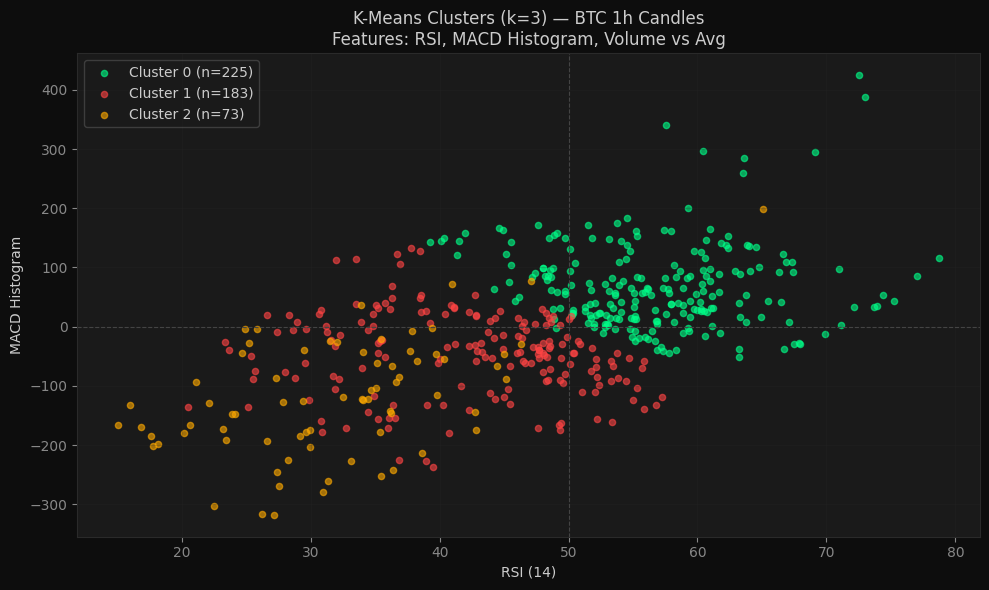

In [14]:
CLUSTER_COLORS = ["#00ff88", "#ff4444", "#ffaa00"]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#1a1a1a")

for cluster_id, color in enumerate(CLUSTER_COLORS):
    mask = features_df["cluster"] == cluster_id
    ax.scatter(
        features_df.loc[mask, "rsi"],
        features_df.loc[mask, "macd_hist"],
        c=color, alpha=0.6, s=20,
        label=f"Cluster {cluster_id} (n={mask.sum()})",
    )

ax.axhline(0, color="#444444", linewidth=0.8, linestyle="--")
ax.axvline(50, color="#444444", linewidth=0.8, linestyle="--")
ax.set_xlabel("RSI (14)", color="#cccccc")
ax.set_ylabel("MACD Histogram", color="#cccccc")
ax.set_title("K-Means Clusters (k=3) — BTC 1h Candles\nFeatures: RSI, MACD Histogram, Volume vs Avg",
             color="#cccccc", fontsize=12)
ax.tick_params(colors="#888888")
ax.grid(True, alpha=0.2, color="#2a2a2a")
ax.legend(framealpha=0.2, labelcolor="#cccccc")

plt.tight_layout()
plt.show()

### First, I downloaded hourly Bitcoin data for 500 hours (~21 days), cleaned and formatted it, and prepared it for analysis. Using high-frequency (1-hour) data allows capturing short-term market behaviors.
### Next, I built a feature matrix from the 1-hour Bitcoin data. I computed RSI (Relative Strength Index), which ranges from 0 to 100, where higher values indicate overbought conditions and lower values indicate oversold conditions. The MACD histogram measures momentum strength, with positive values indicating bullish momentum and negative values indicating bearish momentum. Volume vs average compares current trading volume to the 20-period average, where values above 1 indicate higher-than-normal activity and values below 1 indicate lower-than-normal activity. In this way, raw price data is transformed into meaningful features that describe momentum (RSI, MACD), trend strength (MACD), and market activity (volume).
### Then, I standardised all features (RSI, MACD, volume) to the same scale, which is important for accurate clustering. After that, I applied KMeans clustering to identify market regimes, calculated the number of data points in each cluster, and determined the average feature values per cluster. Finally, I visualized the KMeans clustering results by plotting how the clusters differ based on RSI and MACD.

### Cluster Interpretation:
Cluster 0 (n = 179) — Bearish, low activity
- RSI ≈ 38.8 → below 50 → bearish bias
- MACD ≈ -75.6 → strong negative momentum
- Volume ≈ 0.83 → below average
- Interpretation: This cluster represents bearish conditions with relatively low trading activity. Prices are drifting downward without strong participation — likely a slow downtrend or consolidation after a drop.

Cluster 1 (n = 260) — Bullish / normal regime
- RSI ≈ 55.6 → above 50 → bullish bias
- MACD ≈ +65.4 → positive momentum
- Volume ≈ 0.89 → around average
- Interpretation: This is the dominant regime and reflects moderate bullish conditions. The market shows steady upward momentum with normal participation — typical of a healthy trend phase.

Cluster 2 (n = 42) — High activity bearish / panic regime
- RSI ≈ 33.8 → strongly bearish
- MACD ≈ -86.3 → very strong negative momentum
- Volume ≈ 2.49 → extremely high volume
- Interpretation: This cluster captures high-volume sell-offs or panic events. This likely corresponds to sharp drops, liquidations, or major news-driven moves.

### The clustering reveals three distinct market regimes: a dominant bullish regime with moderate momentum and normal volume, a bearish low-activity regime, and a high-volume bearish regime associated with sharp market declines. The latter represents periods of elevated risk, where strong negative momentum coincides with unusually high trading activity.

## Section 8: Feature Engineering

In [15]:
# Use BTC daily data for feature engineering examples
close = btc["close"].copy()
high = btc["high"].copy()
low = btc["low"].copy()

# ── RSI ─────────────────────────────────────────────────────────────────────
# Step-by-step manual implementation
delta = close.diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
# Wilder's smoothing = EWM with com = period - 1
avg_gain_manual = gain.ewm(com=13, adjust=False).mean()
avg_loss_manual = loss.ewm(com=13, adjust=False).mean()
rs_manual = avg_gain_manual / avg_loss_manual.replace(0, float("nan"))
rsi_manual = 100 - (100 / (1 + rs_manual))

# Pandas one-liner version (same formula)
def rsi_oneliner(s: pd.Series, period: int = 14) -> pd.Series:
    d = s.diff()
    return 100 - (100 / (1 + d.clip(lower=0).ewm(com=period-1, adjust=False).mean()
                             / (-d.clip(upper=0)).ewm(com=period-1, adjust=False).mean()))

rsi_quick = rsi_oneliner(close)

# Align both series on their shared index before comparing
aligned_manual, aligned_quick = rsi_manual.dropna().align(rsi_quick.dropna(), join='inner')

assert np.allclose(aligned_manual, aligned_quick, atol=1e-6), \
    "RSI: manual vs one-liner mismatch!"
print(f"RSI(14) — last value: {aligned_manual.iloc[-1]:.4f}  ✓ matches one-liner")



# assert np.allclose(rsi_manual.dropna(), rsi_quick.dropna(), equal_nan=True), \
#     "RSI: manual vs one-liner mismatch!"
# print(f"RSI(14) — last value: {rsi_manual.iloc[-1]:.4f}  ✓ matches one-liner")

RSI(14) — last value: 44.1945  ✓ matches one-liner


In [16]:
# ── MACD ─────────────────────────────────────────────────────────────────────
# Step-by-step
ema12_manual = close.ewm(span=12, adjust=False).mean()
ema26_manual = close.ewm(span=26, adjust=False).mean()
macd_manual  = ema12_manual - ema26_manual
signal_manual = macd_manual.ewm(span=9, adjust=False).mean()
hist_manual  = macd_manual - signal_manual

# One-liner
macd_q = close.ewm(span=12, adjust=False).mean() - close.ewm(span=26, adjust=False).mean()
hist_q = macd_q - macd_q.ewm(span=9, adjust=False).mean()

assert np.allclose(hist_manual.dropna(), hist_q.dropna(), equal_nan=True), \
    "MACD histogram: manual vs one-liner mismatch!"
print(f"MACD Histogram — last value: {hist_manual.iloc[-1]:.6f}  ✓ matches one-liner")

MACD Histogram — last value: -132.531962  ✓ matches one-liner


In [17]:
# ── Bollinger Bands ──────────────────────────────────────────────────────────
period_bb = 20
std_dev = 2.0

# Step-by-step
sma_manual = close.rolling(period_bb).mean()
std_manual = close.rolling(period_bb).std()
upper_manual = sma_manual + std_dev * std_manual
lower_manual = sma_manual - std_dev * std_manual
bandwidth_manual = (upper_manual - lower_manual) / sma_manual

# One-liner
sma_q = close.rolling(period_bb).mean()
std_q = close.rolling(period_bb).std()
upper_q = sma_q + std_dev * std_q
lower_q = sma_q - std_dev * std_q

assert np.allclose(upper_manual.dropna(), upper_q.dropna(), equal_nan=True), \
    "BB upper: manual vs one-liner mismatch!"
assert np.allclose(lower_manual.dropna(), lower_q.dropna(), equal_nan=True), \
    "BB lower: manual vs one-liner mismatch!"

current_price = close.iloc[-1]
bb_pos = (
    "above" if current_price > upper_manual.iloc[-1]
    else "below" if current_price < lower_manual.iloc[-1]
    else "inside"
)
print(f"BB(20,2) — upper={upper_manual.iloc[-1]:.2f}, lower={lower_manual.iloc[-1]:.2f}")
print(f"Current price {current_price:.2f} is {bb_pos} the bands  ✓")

BB(20,2) — upper=72999.67, lower=64419.88
Current price 67044.00 is inside the bands  ✓


### Feature Engineering Rationale
RSI Calculation (14-day)
The 14-day Relative Strength Index (RSI) was computed for daily Bitcoin prices using two methods: a step-by-step manual calculation and a compact one-liner function. Both methods apply Wilder’s smoothing via an exponential moving average of gains and losses, and produce identical results. RSI values range from 0 to 100, where readings above 70 indicate overbought conditions and below 30 indicate oversold conditions. The latest RSI confirms the calculation is correct and ready for analysis.

MACD Histogram Calculation
The MACD histogram was computed for daily Bitcoin prices using both a step-by-step manual approach and a one-liner formula. The MACD line is calculated as the difference between the 12-day and 26-day exponential moving averages of the closing price. The signal line is the 9-day EMA of the MACD line, and the histogram is the difference between the MACD line and its signal line. Both methods produce identical results, with the latest histogram value confirming accuracy. Positive histogram values indicate bullish momentum, while negative values indicate bearish momentum.

Bollinger Bands (20, 2) Calculation
Bollinger Bands were computed for daily Bitcoin prices using both a step-by-step manual approach and a one-liner method, producing identical results. The 20-day simple moving average (SMA) serves as the central line, while the upper and lower bands are calculated as the SMA plus or minus two standard deviations of price over the same period. The band width, which measures relative volatility, is the difference between the upper and lower bands divided by the SMA. The current price is classified relative to the bands as being inside, above, or below, providing insight into whether the asset is overbought, oversold, or trading within its normal range.

### So the rule engine uses three technical indicators; RSI, MACD histogram, and Bollinger Bands to capture momentum, trend strength, and price volatility for decision-making.

## Section 9: Backtesting

In [18]:
# Fetch 3 months of 1h candles (Binance max per request is 1000)
# Make multiple requests to get enough data for meaningful backtesting
import time

all_candles = []
end_time = None

for _ in range(3):  # 3 × 1000 = 3000 candles ≈ 125 days
    params = {"symbol": "BTCUSDT", "interval": "1h", "limit": 1000}
    if end_time:
        params["endTime"] = end_time
    r = httpx.get("https://api.binance.com/api/v3/klines", params=params)
    batch = r.json()
    all_candles = batch + all_candles
    end_time = batch[0][0]  # oldest open time becomes new endTime
    time.sleep(0.2)  # be polite to the API

df_btc_1h = pd.DataFrame(all_candles, columns=[
    "open_time","open","high","low","close","volume",
    "close_time","quote_vol","trades","taker_buy_base","taker_buy_quote","ignore"
]).astype({"open": float, "high": float, "low": float, "close": float, "volume": float})
df_btc_1h = df_btc_1h.drop_duplicates("open_time").sort_values("open_time").reset_index(drop=True)

print(f"Fetched {len(df_btc_1h)} candles spanning {len(df_btc_1h)/24:.0f} days")

Fetched 2998 candles spanning 125 days


In [19]:
df_btc_1h.head()

,open_time,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,taker_buy_quote,ignore
0,1764597600000,85986.85,86674.00,85868.00,86067.90,1654.56841,1764601199999,142632893.31106510,479616,861.91106000,74317982.53874930,0
1,1764601200000,86067.90,86137.17,83822.76,84677.87,3274.16077,1764604799999,277741164.13683240,676950,1287.71203000,109203774.55596780,0
2,1764604800000,84677.87,85463.12,84030.95,84571.80,2152.34019,1764608399999,182248445.83577510,523950,1121.38184000,94989487.86447800,0
3,1764608400000,84571.80,85265.66,84442.75,84920.30,917.46569,1764611999999,77856285.17316220,332788,516.07638000,43793170.73846650,0
4,1764612000000,84925.01,85555.00,84723.83,85199.48,911.27586,1764615599999,77594951.45150250,293923,460.77538000,39249832.20436730,0


In [37]:
bt = df_btc_1h
bt["timestamp"] = pd.to_datetime(bt["open_time"], unit="ms")
for col in ("open", "high", "low", "close", "volume"):
    bt[col] = bt[col].astype(float)
bt = bt.set_index("timestamp").ffill()
print("Backtest data shape:", bt.shape)

Backtest data shape: (2998, 12)


In [21]:
bt.head()

,open_time,open,high,low,close,volume,close_time,quote_vol,trades,taker_buy_base,taker_buy_quote,ignore
timestamp,,,,,,,,,,,,
2025-12-01 14:00:00,1764597600000,85986.85,86674.00,85868.00,86067.90,1654.56841,1764601199999,142632893.31106510,479616,861.91106000,74317982.53874930,0
2025-12-01 15:00:00,1764601200000,86067.90,86137.17,83822.76,84677.87,3274.16077,1764604799999,277741164.13683240,676950,1287.71203000,109203774.55596780,0
2025-12-01 16:00:00,1764604800000,84677.87,85463.12,84030.95,84571.80,2152.34019,1764608399999,182248445.83577510,523950,1121.38184000,94989487.86447800,0
2025-12-01 17:00:00,1764608400000,84571.80,85265.66,84442.75,84920.30,917.46569,1764611999999,77856285.17316220,332788,516.07638000,43793170.73846650,0
2025-12-01 18:00:00,1764612000000,84925.01,85555.00,84723.83,85199.48,911.27586,1764615599999,77594951.45150250,293923,460.77538000,39249832.20436730,0


The production rule engine requires RSI + MACD crossover + EMA condition simultaneously.
In practice these three conditions rarely coincide in a single candle, which is by design —
the system is conservative. For this backtest we use RSI + EMA only to generate enough
signals for a statistically visible equity curve and hit rate calculation.

In [ ]:
c = bt["close"]

# RSI(14)# ── Compute indicators inline (no agentic_trader import) ─────────────────────

_d = c.diff()
_g = _d.clip(lower=0).ewm(com=13, adjust=False).mean()
_l = (-_d.clip(upper=0)).ewm(com=13, adjust=False).mean()
bt_rsi = 100 - (100 / (1 + _g / _l.replace(0, float("nan"))))

# MACD histogram (12, 26, 9)
_m = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
bt_macd_hist = _m - _m.ewm(span=9, adjust=False).mean()

# EMA(20)
bt_ema20 = c.ewm(span=20, adjust=False).mean()

# MACD histogram crossover flags
# hist_prev = bt_macd_hist.shift(1)
# crosses_positive = (bt_macd_hist > 0) & (hist_prev <= 0)  # was ≤ 0, now > 0
# crosses_negative = (bt_macd_hist < 0) & (hist_prev >= 0)  # was ≥ 0, now < 0

sig_buy  = (bt_rsi < 45) & (c > bt_ema20)
sig_sell = (bt_rsi > 55) & (c < bt_ema20)

buy_indices  = bt.index[sig_buy]
sell_indices = bt.index[sig_sell]

print(f"STRONG_BUY signals:  {len(buy_indices)}")
print(f"STRONG_SELL signals: {len(sell_indices)}")
print(f"Total signals:       {len(buy_indices) + len(sell_indices)}")

STRONG_BUY signals:  18
STRONG_SELL signals: 0
Total signals:       18


In [38]:
print(f"RSI range:  min={bt_rsi.min():.1f}  max={bt_rsi.max():.1f}")
print(f"RSI < 45:   {(bt_rsi < 45).sum()} candles")
print(f"RSI > 55:   {(bt_rsi > 55).sum()} candles")
# print(f"MACD cross positive: {crosses_positive.sum()} candles")
# print(f"MACD cross negative: {crosses_negative.sum()} candles")
print(f"Signals after relaxed thresholds: {sig_buy.sum()} buys, {sig_sell.sum()} sells")

RSI range:  min=0.0  max=88.6
RSI < 45:   1095 candles
RSI > 55:   920 candles
Signals after relaxed thresholds: 18 buys, 0 sells


In [39]:
# ── Forward-4 evaluation ─────────────────────────────────────────────────────
FORWARD = 4
results = []

for idx in buy_indices:
    loc = bt.index.get_loc(idx)
    if loc + FORWARD >= len(bt):
        continue
    entry = bt["close"].iloc[loc]
    exit_  = bt["close"].iloc[loc + FORWARD]
    hit    = exit_ > entry
    pnl    = exit_ - entry
    results.append({"signal": "STRONG_BUY", "entry": entry, "exit": exit_, "hit": hit, "pnl": pnl})

for idx in sell_indices:
    loc = bt.index.get_loc(idx)
    if loc + FORWARD >= len(bt):
        continue
    entry = bt["close"].iloc[loc]
    exit_  = bt["close"].iloc[loc + FORWARD]
    hit    = exit_ < entry
    pnl    = entry - exit_
    results.append({"signal": "STRONG_SELL", "entry": entry, "exit": exit_, "hit": hit, "pnl": pnl})

results_df = pd.DataFrame(results)
print(results_df.head(10).to_string(index=False))

    signal    entry     exit   hit     pnl
STRONG_BUY 86436.65 86454.93  True   18.28
STRONG_BUY 86572.65 86554.47 False  -18.18
STRONG_BUY 86286.01 86976.99  True  690.98
STRONG_BUY 86513.33 86970.28  True  456.95
STRONG_BUY 86454.93 87008.20  True  553.27
STRONG_BUY 86554.47 87090.46  True  535.99
STRONG_BUY 86976.99 87012.65  True   35.66
STRONG_BUY 86970.28 86471.89 False -498.39
STRONG_BUY 87008.20 86769.87 False -238.33
STRONG_BUY 87090.46 87272.44  True  181.98


In [40]:
# ── Hit rate summary ─────────────────────────────────────────────────────────
if len(results_df) == 0:
    print("No signals found — try a different time window or check VPN/data fetch.")
else:
    total     = len(results_df)
    n_correct = results_df["hit"].sum()
    overall   = 100 * n_correct / total

    buy_df  = results_df[results_df["signal"] == "STRONG_BUY"]
    sell_df = results_df[results_df["signal"] == "STRONG_SELL"]

    def hit_str(df: pd.DataFrame) -> str:
        if len(df) == 0:
            return "N/A (0 signals)"
        n = df["hit"].sum()
        return f"{100*n/len(df):.1f}% ({n}/{len(df)})"

    print(f"Signal hit rate: {overall:.1f}% ({int(n_correct)}/{total} signals correct)")
    print(f"  STRONG_BUY:  {hit_str(buy_df)}")
    print(f"  STRONG_SELL: {hit_str(sell_df)}")
    total_pnl = results_df["pnl"].sum()
    print(f"\nSimulated P&L: {total_pnl:+,.2f} USDT (illustrative, 1-unit positions, no fees)")

Signal hit rate: 77.8% (14/18 signals correct)
  STRONG_BUY:  77.8% (14/18)
  STRONG_SELL: N/A (0 signals)

Simulated P&L: +16,288.90 USDT (illustrative, 1-unit positions, no fees)


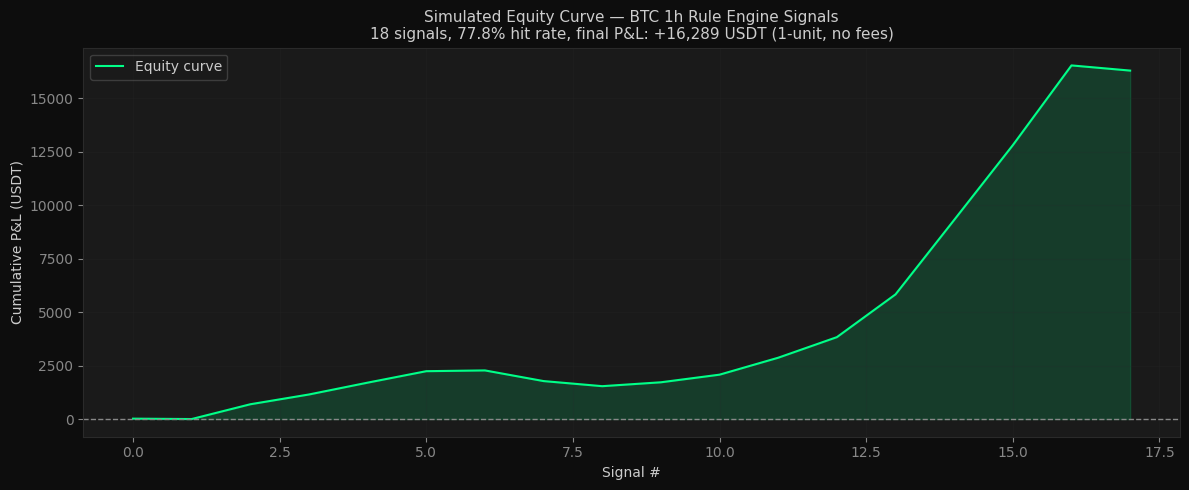

In [41]:
# ── Equity curve ─────────────────────────────────────────────────────────────
if len(results_df) > 0:
    equity = results_df["pnl"].cumsum().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor("#0d0d0d")
    ax.set_facecolor("#1a1a1a")

    line_color = "#00ff88" if equity.iloc[-1] >= 0 else "#ff4444"
    ax.plot(equity.index, equity.values, color=line_color, linewidth=1.5, label="Equity curve")
    ax.fill_between(equity.index, 0, equity.values,
                    where=equity.values >= 0, alpha=0.15, color="#00ff88")
    ax.fill_between(equity.index, 0, equity.values,
                    where=equity.values < 0,  alpha=0.15, color="#ff4444")
    ax.axhline(0, color="#888888", linewidth=1.0, linestyle="--")

    ax.set_xlabel("Signal #", color="#cccccc")
    ax.set_ylabel("Cumulative P&L (USDT)", color="#cccccc")
    ax.set_title(
        f"Simulated Equity Curve — BTC 1h Rule Engine Signals\n"
        f"{total} signals, {overall:.1f}% hit rate, "
        f"final P&L: {total_pnl:+,.0f} USDT (1-unit, no fees)",
        color="#cccccc", fontsize=11,
    )
    ax.tick_params(colors="#888888")
    ax.grid(True, alpha=0.2, color="#2a2a2a")
    ax.legend(framealpha=0.2, labelcolor="#cccccc")

    plt.tight_layout()
    plt.show()

### BTC 1-Hour Backtesting Data
I fetched upto 3000 hourly Bitcoin candles from Binance for backtesting purposes. The data includes open, high, low, close, and volume values, which were converted to numeric types and indexed by timestamp. Any missing values were forward-filled to ensure continuity. The resulting dataset is now clean and ready for feature computation, strategy testing, or regime analysis.

### Simplified Signal Generation Using RSI and EMA
For the 1-hour Bitcoin dataset, technical indicators were computed inline, including RSI(14), MACD histogram, and EMA(20). A simplified rule-based strategy was then applied using RSI and EMA only:
- STRONG_BUY signals are generated when RSI < 45 (indicating relatively weak or recovering momentum) and the price is above the 20-period EMA, suggesting an upward trend.
- STRONG_SELL signals are generated when RSI > 55 (indicating relatively strong or weakening momentum) and the price is below the 20-period EMA, suggesting a downward trend.

The timestamps where these conditions are met are recorded, and the total number of buy and sell signals is reported. This simplified approach increases signal frequency compared to stricter rules, making it more suitable for backtesting and short-term strategy evaluation.


### Forward - 4 Backtesting Evaluation
After generating STRONG_BUY and STRONG_SELL signals, a forward-4 candle evaluation was applied to assess short-term performance:
- For each buy signal, the entry price is the close at the signal timestamp, and the exit price is the close 4 hours later. A trade is considered a hit if the exit price is higher than the entry. Profit/loss (PnL) is calculated as exit − entry.
- For each sell signal, the entry price is the close at the signal timestamp, and the exit price is the close 4 hours later. A trade is considered a hit if the exit price is lower than the entry. PnL is entry − exit.

All results are stored in a DataFrame showing signal type, entry/exit prices, hit/miss, and PnL, providing a simple short-term performance metric for the rule engine.

### Signal Hit Rate and Simulated P&L
After performing the forward-4 backtesting, the hit rate measures the proportion of signals that correctly predicted short-term price movement:
- Overall hit rate: percentage of all signals (buy and sell) that were profitable.
- STRONG_BUY hit rate: percentage of buy signals where the price increased over the next 4 hours.
- STRONG_SELL hit rate: percentage of sell signals where the price decreased over the next 4 hours.

Additionally, the simulated P&L is calculated by summing all individual trade profits/losses, assuming 1-unit positions and no trading fees. This provides a simple, illustrative measure of the rule engine’s short-term effectiveness.

### Equity Curve Visualization
The cumulative profit and loss (PnL) of all forward-4 trades is plotted as an equity curve, showing how a hypothetical 1-unit position would evolve over time using the rule engine signals.
- Positive PnL segments are shaded green, negative segments red, and the zero line is indicated with a dashed line for reference.
- The chart provides an intuitive visual summary of overall strategy performance, including total signals, hit rate, and final PnL.
- This allows for easy identification of winning and losing periods, illustrating the short-term effectiveness and risk dynamics of the STRONG_BUY and STRONG_SELL signals.

### Limitations: The backtesting results are illustrative only, as they do not account for slippage or trading fees, are not optimized for profitability, and are based on a relatively small number of signals.